In [6]:
import pandas as pd
import json
import os

print(os.getcwd())

os.chdir(r"C:\Users\Nicholas Uhorchak\OneDrive - University of Arkansas\Desktop\Vaccine_Tender")

with open(r"Deterministic\Model objective analysis\quantity discount\results\UG_test_no_W\NEW\MVP_DE_results_T_10_delta_5_scen_1_trial_1_inv_1_cap._1_cap.inc._1.json") as f:
    data = json.load(f)

print(type(data['Q']))

# helper: unwrap nested leaf values safely
def unwrap(v):
    while isinstance(v, dict):
        v = next(iter(v.values()))
    return v


# 1. Flatten Q [vaccine][producer][start][end][discount]
q_list = []
for vaccine, producers in data['Q'].items():
    for producer, starts in producers.items():
        for s, ends in starts.items():
            for e, discounts in ends.items():
                for d, val in discounts.items():
                    val = unwrap(val)
                    if val > 0:
                        q_list.append({
                            'vaccine': vaccine,
                            'producer': producer,
                            'start_time': int(s),
                            'end_time': int(e),
                            'discount_level': int(d),
                            'Q_val': val
                        })

df_q = pd.DataFrame(q_list)


# 2. Flatten X [vaccine][producer][time]
x_list = []

for vaccine, producers in data['X'].items():
    for producer, times in producers.items():
        for t, scenarios in times.items():
            
            # collapse scenario dict → scalar (sum across scenarios)
            val = sum(scenarios.values())

            if val > 0:
                x_list.append({
                    'vaccine': vaccine,
                    'producer': producer,
                    'time': int(t),
                    'X_val': val
                })

df_x = pd.DataFrame(x_list)


# 3. Relational Join (non-equi)
df_mapped = pd.merge(df_x, df_q, on=['vaccine', 'producer'], how='left')

df_mapped = df_mapped[
    (df_mapped['time'] >= df_mapped['start_time']) &
    (df_mapped['time'] <= df_mapped['end_time'])
]

print(df_mapped[['vaccine', 'producer', 'start_time', 'end_time', 'time', 'Q_val', 'X_val']])

C:\Users\Nicholas Uhorchak\OneDrive - University of Arkansas\Desktop\Vaccine_Tender
<class 'dict'>
     vaccine producer  start_time  end_time  time         Q_val        X_val
3        PCV   Pfizer           6        10    10      1.417062      0.70694
6        PCV   Pfizer           7        10    10      1.417062      0.70694
9        PCV   Pfizer          10        10    10      0.706940      0.70694
10       PCV   Pfizer           9        10    10      0.706940      0.70694
11       PCV   Pfizer           8        10    10      1.417062      0.70694
...      ...      ...         ...       ...   ...           ...          ...
4860     OPV   PT_Bio           7         9     9  60100.000000  60000.00000
4867     OPV   PT_Bio           9        10     9  60000.000000  60000.00000
4868     OPV   PT_Bio           9         9     9  60000.000000  60000.00000
4869     OPV   PT_Bio           8        10     9  60000.000000  60000.00000
4870     OPV   PT_Bio           8         9     9  600

In [7]:
# Group by the unique contract identifiers to aggregate the X values
analysis_df = (
    df_mapped.groupby(
        [
            "vaccine",
            "producer",
            "start_time",
            "end_time",
            "discount_level",
            "Q_val",
        ]
    )
    .agg(
        Sum_of_X=("X_val", "sum"),
        Periods_Count=(
            "time",
            "count",
        ),  # Count how many time periods contributed
    )
    .reset_index()
)

# Calculate the difference between the contract volume (Q) and the sum of deliveries (X)
analysis_df["Discrepancy"] = analysis_df["Sum_of_X"] - analysis_df["Q_val"]

# Flag rows where they don't match (using a tiny tolerance for floating-point issues)
analysis_df["Is_Match"] = analysis_df["Discrepancy"].abs() < 1e-2

# --- Print out the Verification Report ---
mismatches = analysis_df[~analysis_df["Is_Match"]]

print("=" * 60)
print(f"Total Unique Contracts Evaluated: {len(analysis_df)}")
print("=" * 60)

if mismatches.empty:
    print(
        "✅ PERFECT MATCH: For every contract window, the sum of the associated"
    )
    print("   X values perfectly equals the contract quantity Q_val.")
else:
    print(
        f"❌ MISMATCH DETECTED: Found {len(mismatches)} contract(s) where sum(X) != Q"
    )
    print("\nDisplaying Mismatches:")
    print(
        mismatches[
            [
                "vaccine",
                "producer",
                "start_time",
                "end_time",
                "Q_val",
                "Sum_of_X",
                "Discrepancy",
            ]
        ]
    )

print("=" * 60)

Total Unique Contracts Evaluated: 817
✅ PERFECT MATCH: For every contract window, the sum of the associated
   X values perfectly equals the contract quantity Q_val.


In [8]:
# Group your flattened DataFrames from the previous step
total_Q = df_q.groupby(['vaccine', 'producer'])['Q_val'].sum()
total_X = df_x.groupby(['vaccine', 'producer'])['X_val'].sum()

# Combine to check for gaps
comparison = pd.DataFrame({'Total_Q': total_Q, 'Total_X': total_X}).fillna(0)
comparison['Q_minus_X'] = comparison['Total_Q'] - comparison['Total_X']

# Filter for instances where commitment exceeded actual physical delivery
imbalances = comparison[comparison['Q_minus_X'] > 1e-4]
print(imbalances)

                                Total_Q       Total_X     Q_minus_X
vaccine   producer                                                 
DT        BB_NCIPD         6.612250e+05  6.316500e+04  5.980600e+05
          PT_Bio           1.381111e+06  1.202000e+05  1.260911e+06
DTwP      Biological_E     1.375066e+06  1.202000e+05  1.254866e+06
DTwP-Hib  Serum_Institute  6.334818e+05  5.096980e+04  5.825120e+05
HPV       Merck_Sharp      1.950216e+00  3.900432e-01  1.560173e+00
Hexa      Sanofi           6.728450e+05  6.010000e+04  6.127450e+05
IPV       AJ_Vaccines      2.167629e+07  2.281260e+06  1.939503e+07
          Bilthoven        2.922365e+06  2.881600e+05  2.634205e+06
OPV       Bharat_Biotech   7.212000e+05  6.010000e+04  6.611000e+05
          China_National   1.441770e+06  1.680940e+05  1.273676e+06
          GSK              1.405640e+06  1.202000e+05  1.285440e+06
          Haffkine_Bio     1.266900e+06  1.128800e+05  1.154020e+06
          PT_Bio           1.442300e+06  1.20200

In [9]:
df_match = df_mapped.groupby('time')[['X_val','Q_val']].sum().reset_index()

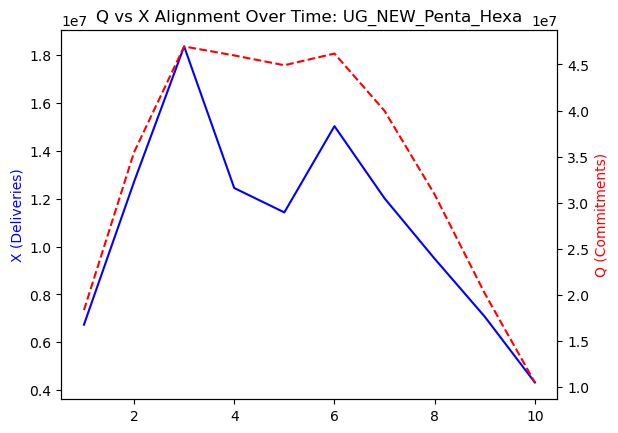

In [10]:
from matplotlib import pyplot as plt
fig, ax1 = plt.subplots()

ax1.plot(df_match['time'], df_match['X_val'], 'b-', label='X')
ax1.set_ylabel('X (Deliveries)', color='b')

ax2 = ax1.twinx()
ax2.plot(df_match['time'], df_match['Q_val'], 'r--', label='Q')
ax2.set_ylabel('Q (Commitments)', color='r')

plt.title("Q vs X Alignment Over Time: UG_NEW_Penta_Hexa")
plt.savefig("UG_NEW_Penta_Hexa.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
import os
import json
import glob
import numpy as np
import pandas as pd
import scipy.stats as stats

# Helper: unwrap nested leaf values safely
def unwrap(v):
    while isinstance(v, dict):
        v = next(iter(v.values()))
    return v

def analyze_single_file(file_path):
    """
    Processes a single JSON file and returns the count of mismatched contracts.
    """
    if not os.path.exists(file_path):
        print(f"⚠️ Warning: File not found: {file_path}")
        return None
        
    with open(file_path, 'r') as f:
        data = json.load(f)
        
    # 1. Flatten Q
    q_list = []
    for vaccine, producers in data['Q'].items():
        for producer, starts in producers.items():
            for s, ends in starts.items():
                for e, discounts in ends.items():
                    for d, val in discounts.items():
                        val = unwrap(val)
                        if val > 0:
                            q_list.append({
                                'vaccine': vaccine,
                                'producer': producer,
                                'start_time': int(s),
                                'end_time': int(e),
                                'discount_level': int(d),
                                'Q_val': val
                            })
    if not q_list:
        return 0
    df_q = pd.DataFrame(q_list)

    # 2. Flatten X
    x_list = []
    for vaccine, producers in data['X'].items():
        for producer, times in producers.items():
            for t, scenarios in times.items():
                val = sum(scenarios.values())
                if val > 0:
                    x_list.append({
                        'vaccine': vaccine,
                        'producer': producer,
                        'time': int(t),
                        'X_val': val
                    })
    if not x_list:
        return len(df_q) # If no X deliveries, all active Q are mismatches
    df_x = pd.DataFrame(x_list)

    # 3. Relational Join (non-equi)
    df_mapped = pd.merge(df_x, df_q, on=['vaccine', 'producer'], how='left')
    df_mapped = df_mapped[
        (df_mapped['time'] >= df_mapped['start_time']) &
        (df_mapped['time'] <= df_mapped['end_time'])
    ]

    if df_mapped.empty:
        return len(df_q)

    # 4. Group by contract context to verify
    analysis_df = (
        df_mapped.groupby(["vaccine", "producer", "start_time", "end_time", "discount_level", "Q_val"])
        .agg(Sum_of_X=("X_val", "sum"))
        .reset_index()
    )

    # 5. Find mismatches
    analysis_df["Discrepancy"] = analysis_df["Sum_of_X"] - analysis_df["Q_val"]
    analysis_df["Is_Match"] = analysis_df["Discrepancy"].abs() < 1e-2
    
    num_mismatches = len(analysis_df[~analysis_df["Is_Match"]])
    
    # Account for any contracts in Q that never received any X mapping whatsoever
    missing_contracts = len(df_q) - len(analysis_df)
    total_mismatches = num_mismatches + max(0, missing_contracts)
    
    return total_mismatches

# ==========================================
# MAIN EXECUTION LOOP
# ==========================================

# Base template directory and file structure
base_dir = os.path.join("Deterministic", "Model objective analysis", "quantity discount", "results", "buyer discounts", "2 segments", "mp")

mismatch_counts = []

# Approach A: Explicit loop if your files are strictly named trial_1 to trial_30
for trial in range(1, 31):
    file_name = f"MVP_DE_results_T_10_delta_5_scen_1_trial_{trial}_inv_1_cap._1_cap.inc._1.json"
    file_path = os.path.join(base_dir, file_name)
    
    count = analyze_single_file(file_path)
    if count is not None:
        mismatch_counts.append(count)

# Approach B: Alternative dynamic directory scanning (Uncomment if names vary slightly)
# search_path = os.path.join(base_dir, "MVP_DE_results_T_10_delta_5_scen_1_trial_*_inv_1_cap._1_cap.inc._1.json")
# for file_path in glob.glob(search_path):
#     count = analyze_single_file(file_path)
#     if count is not None:
#         mismatch_counts.append(count)


# ==========================================
# STATISTICAL ANALYSIS (95% CI)
# ==========================================
n = len(mismatch_counts)

if n >= 2:
    mean_mismatches = np.mean(mismatch_counts)
    sem = stats.sem(mismatch_counts) # Standard Error of the Mean
    
    # 95% Confidence Interval using a Student's t-distribution (ideal for small sample size n=30)
    ci_lower, ci_upper = stats.t.interval(0.95, df=n-1, loc=mean_mismatches, scale=sem)
    
    print("\n" + "="*60)
    print("             BATCH RUN ANALYSIS REPORT              ")
    print("="*60)
    print(f"Total Successful Files Processed: {n}")
    print(f"Raw Mismatch Counts:              {mismatch_counts}")
    print("-"*60)
    print(f"Average Mismatches Detected:     {mean_mismatches:.3f}")
    print(f"95% Confidence Interval (CI):    [{ci_lower:.3f}, {ci_upper:.3f}]")
    print("="*60)
else:
    print(f"❌ Error: Not enough data points to compute stats. Only processed {n} files.")

🚨 Plot successfully generated and saved as 'isolated_mismatches.png'
                                  Contract_Label  ...  Discrepancy
0           IPV (LG_Chem)\nWindow: 9-10 | Lvl: 2  ...    -142130.0
1           IPV (LG_Chem)\nWindow: 7-10 | Lvl: 2  ...     -82030.0
2     OPV (Bharat_Biotech)\nWindow: 9-9 | Lvl: 1  ...     -59820.0
3     OPV (Bharat_Biotech)\nWindow: 8-8 | Lvl: 1  ...     -55660.0
4   OPV (Bharat_Biotech)\nWindow: 10-10 | Lvl: 1  ...     -52680.0
5     OPV (Panacea_Biotec)\nWindow: 4-5 | Lvl: 1  ...     -48450.0
6     OPV (Panacea_Biotec)\nWindow: 4-6 | Lvl: 1  ...     -48450.0
7    OPV (Panacea_Biotec)\nWindow: 9-10 | Lvl: 1  ...     -48450.0
8    Penta (Biological_E)\nWindow: 7-10 | Lvl: 2  ...     -44540.0
9      DTwP (Biological_E)\nWindow: 5-9 | Lvl: 1  ...     -41695.0
10    OPV (Panacea_Biotec)\nWindow: 6-7 | Lvl: 1  ...     -40720.0
11    OPV (Panacea_Biotec)\nWindow: 5-7 | Lvl: 1  ...     -40720.0
12    DTwP (Biological_E)\nWindow: 6-10 | Lvl: 1  ...     -3

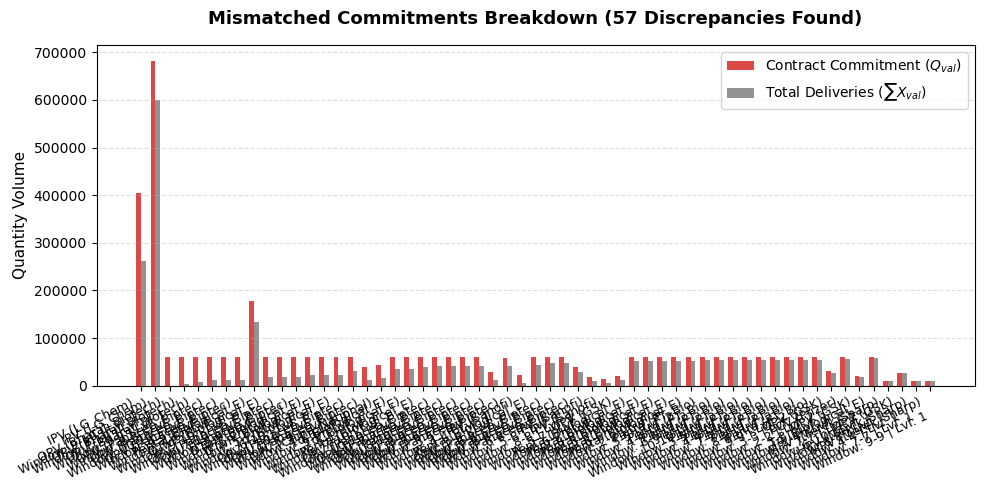

In [60]:
import json
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# Helper: unwrap nested leaf values safely
def unwrap(v):
    while isinstance(v, dict):
        v = next(iter(v.values()))
    return v


# 1. Load data from a single instance
file_path = r"Deterministic\Model objective analysis\quantity discount\results\buyer discounts\2 segments\SBROI\MVP_DE_results_T_10_delta_5_scen_1_trial_1_inv_1_cap._1_cap.inc._1.json"

with open(file_path, "r") as f:
    data = json.load(f)

# 2. Flatten Q [vaccine][producer][start][end][discount]
q_list = []
for vaccine, producers in data["Q"].items():
    for producer, starts in producers.items():
        for s, ends in starts.items():
            for e, discounts in ends.items():
                for d, val in discounts.items():
                    val = unwrap(val)
                    if val > 0:
                        q_list.append(
                            {
                                "vaccine": vaccine,
                                "producer": producer,
                                "start_time": int(s),
                                "end_time": int(e),
                                "discount_level": int(d),
                                "Q_val": val,
                            }
                        )
df_q = pd.DataFrame(q_list)

# 3. Flatten X [vaccine][producer][time]
x_list = []
for vaccine, producers in data["X"].items():
    for producer, times in producers.items():
        for t, scenarios in times.items():
            val = sum(scenarios.values())
            if val > 0:
                x_list.append(
                    {
                        "vaccine": vaccine,
                        "producer": producer,
                        "time": int(t),
                        "X_val": val,
                    }
                )
df_x = pd.DataFrame(x_list)

# 4. Relational Non-Equi Join
df_mapped = pd.merge(df_x, df_q, on=["vaccine", "producer"], how="left")
df_mapped = df_mapped[
    (df_mapped["time"] >= df_mapped["start_time"])
    & (df_mapped["time"] <= df_mapped["end_time"])
]

# 5. Group by contract to sum X values
analysis_df = (
    df_mapped.groupby(
        [
            "vaccine",
            "producer",
            "start_time",
            "end_time",
            "discount_level",
            "Q_val",
        ]
    )
    .agg(Sum_of_X=("X_val", "sum"))
    .reset_index()
)

# 6. FILTER OUT PERFECT MATCHES
# We calculate the absolute discrepancy and drop everything within our tolerance
analysis_df["Discrepancy"] = analysis_df["Sum_of_X"] - analysis_df["Q_val"]
mismatches_df = analysis_df[analysis_df["Discrepancy"].abs() >= 1e-2].copy()

# ==========================================
# PLOTTING THE MISMATCHES (IF ANY EXIST)
# ==========================================
if mismatches_df.empty:
    print(
        "🎉 Clean slate! No chart generated because 100% of the contracts matched perfectly."
    )
else:
    # Create clean labels for the mismatched entries
    mismatches_df["Contract_Label"] = (
        mismatches_df["vaccine"]
        + " ("
        + mismatches_df["producer"]
        + ")\nWindow: "
        + mismatches_df["start_time"].astype(str)
        + "-"
        + mismatches_df["end_time"].astype(str)
        + " | Lvl: "
        + mismatches_df["discount_level"].astype(str)
    )

    # Sort descending by the size of the commitment gap
    mismatches_df["Absolute_Error"] = mismatches_df["Discrepancy"].abs()
    mismatches_df = mismatches_df.sort_values(
        by="Absolute_Error", ascending=False
    ).reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(10, 5))

    x_indices = np.arange(len(mismatches_df))
    bar_width = 0.35

    # Side-by-side comparison for the broken thresholds
    ax.bar(
        x_indices - bar_width / 2,
        mismatches_df["Q_val"],
        bar_width,
        label="Contract Commitment ($Q_{val}$)",
        color="#d62728",
        alpha=0.85,
    )  # Red for target
    ax.bar(
        x_indices + bar_width / 2,
        mismatches_df["Sum_of_X"],
        bar_width,
        label="Total Deliveries ($\sum X_{val}$)",
        color="#7f7f7f",
        alpha=0.85,
    )  # Gray for execution

    # Chart Polish
    ax.set_ylabel("Quantity Volume", fontsize=11)
    ax.set_title(
        f"Mismatched Commitments Breakdown ({len(mismatches_df)} Discrepancies Found)",
        fontsize=13,
        fontweight="bold",
        pad=15,
    )
    ax.set_xticks(x_indices)
    ax.set_xticklabels(
        mismatches_df["Contract_Label"], rotation=25, ha="right", fontsize=9
    )
    ax.legend(fontsize=10)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    plt.tight_layout()

    # Save the isolated discrepancies chart
    plt.savefig("isolated_mismatches.png", dpi=300)
    print(
        f"🚨 Plot successfully generated and saved as 'isolated_mismatches.png'"
    )
    print(mismatches_df[["Contract_Label", "Q_val", "Sum_of_X", "Discrepancy"]])